### Initial Set Up

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('vehicle_maintenance_data.csv')
df.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,11/23/2023,6/24/2025,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,9/21/2023,6/4/2025,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,6/27/2023,4/27/2025,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,8/24/2023,11/5/2025,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,5/25/2023,9/14/2025,Third,16446,6,2,16.977483,Good,Good,Weak,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle_Model         50000 non-null  object 
 1   Mileage               50000 non-null  int64  
 2   Maintenance_History   50000 non-null  object 
 3   Reported_Issues       50000 non-null  int64  
 4   Vehicle_Age           50000 non-null  int64  
 5   Fuel_Type             50000 non-null  object 
 6   Transmission_Type     50000 non-null  object 
 7   Engine_Size           50000 non-null  int64  
 8   Odometer_Reading      50000 non-null  int64  
 9   Last_Service_Date     50000 non-null  object 
 10  Warranty_Expiry_Date  50000 non-null  object 
 11  Owner_Type            50000 non-null  object 
 12  Insurance_Premium     50000 non-null  int64  
 13  Service_History       50000 non-null  int64  
 14  Accident_History      50000 non-null  int64  
 15  Fuel_Efficiency    

In [9]:
df.describe()

,Mileage,Reported_Issues,Vehicle_Age,Engine_Size,Odometer_Reading,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Need_Maintenance
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,54931.232680,2.497420,5.492260,1556.292000,75551.187060,17465.340700,5.515560,1.50156,14.990323,0.809960
std,14401.912925,1.708781,2.875682,627.677218,43088.105658,7223.393401,2.874899,1.11951,2.885583,0.392336
min,30001.000000,0.000000,1.000000,800.000000,1001.000000,5000.000000,1.000000,0.00000,10.000098,0.000000
25%,42471.500000,1.000000,3.000000,1000.000000,38009.000000,11189.750000,3.000000,0.00000,12.489037,1.000000
50%,54810.000000,2.000000,5.000000,1500.000000,75598.500000,17477.500000,6.000000,2.00000,14.986352,1.000000
75%,67391.500000,4.000000,8.000000,2000.000000,112999.500000,23692.000000,8.000000,3.00000,17.474676,1.000000
max,80000.000000,5.000000,10.000000,2500.000000,149999.000000,30000.000000,10.000000,3.00000,19.999968,1.000000


### EDA

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("vehicle_maintenance_data.csv")
display(df.head(), df.shape)

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,11/23/2023,6/24/2025,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,9/21/2023,6/4/2025,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,6/27/2023,4/27/2025,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,8/24/2023,11/5/2025,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,5/25/2023,9/14/2025,Third,16446,6,2,16.977483,Good,Good,Weak,1


(50000, 20)

In [11]:
print("Info:")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

display(df.describe(include="all"))

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle_Model         50000 non-null  object 
 1   Mileage               50000 non-null  int64  
 2   Maintenance_History   50000 non-null  object 
 3   Reported_Issues       50000 non-null  int64  
 4   Vehicle_Age           50000 non-null  int64  
 5   Fuel_Type             50000 non-null  object 
 6   Transmission_Type     50000 non-null  object 
 7   Engine_Size           50000 non-null  int64  
 8   Odometer_Reading      50000 non-null  int64  
 9   Last_Service_Date     50000 non-null  object 
 10  Warranty_Expiry_Date  50000 non-null  object 
 11  Owner_Type            50000 non-null  object 
 12  Insurance_Premium     50000 non-null  int64  
 13  Service_History       50000 non-null  int64  
 14  Accident_History      50000 non-null  int64  
 15  Fuel_Efficien

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
count,50000,50000.000000,50000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000,50000,50000,50000.000000,50000.000000,50000.00000,50000.000000,50000,50000,50000,50000.000000
unique,6,NaN,3,NaN,NaN,3,2,NaN,NaN,336,701,3,NaN,NaN,NaN,NaN,3,3,3,NaN
top,Bus,NaN,Average,NaN,NaN,Diesel,Manual,NaN,NaN,11/25/2023,9/16/2024,Second,NaN,NaN,NaN,NaN,New,Worn Out,New,NaN
freq,8414,NaN,16724,NaN,NaN,16738,25009,NaN,NaN,182,101,16875,NaN,NaN,NaN,NaN,16825,16685,16725,NaN
mean,NaN,54931.232680,NaN,2.497420,5.492260,NaN,NaN,1556.292000,75551.187060,NaN,NaN,NaN,17465.340700,5.515560,1.50156,14.990323,NaN,NaN,NaN,0.809960
std,NaN,14401.912925,NaN,1.708781,2.875682,NaN,NaN,627.677218,43088.105658,NaN,NaN,NaN,7223.393401,2.874899,1.11951,2.885583,NaN,NaN,NaN,0.392336
min,NaN,30001.000000,NaN,0.000000,1.000000,NaN,NaN,800.000000,1001.000000,NaN,NaN,NaN,5000.000000,1.000000,0.00000,10.000098,NaN,NaN,NaN,0.000000
25%,NaN,42471.500000,NaN,1.000000,3.000000,NaN,NaN,1000.000000,38009.000000,NaN,NaN,NaN,11189.750000,3.000000,0.00000,12.489037,NaN,NaN,NaN,1.000000
50%,NaN,54810.000000,NaN,2.000000,5.000000,NaN,NaN,1500.000000,75598.500000,NaN,NaN,NaN,17477.500000,6.000000,2.00000,14.986352,NaN,NaN,NaN,1.000000
75%,NaN,67391.500000,NaN,4.000000,8.000000,NaN,NaN,2000.000000,112999.500000,NaN,NaN,NaN,23692.000000,8.000000,3.00000,17.474676,NaN,NaN,NaN,1.000000


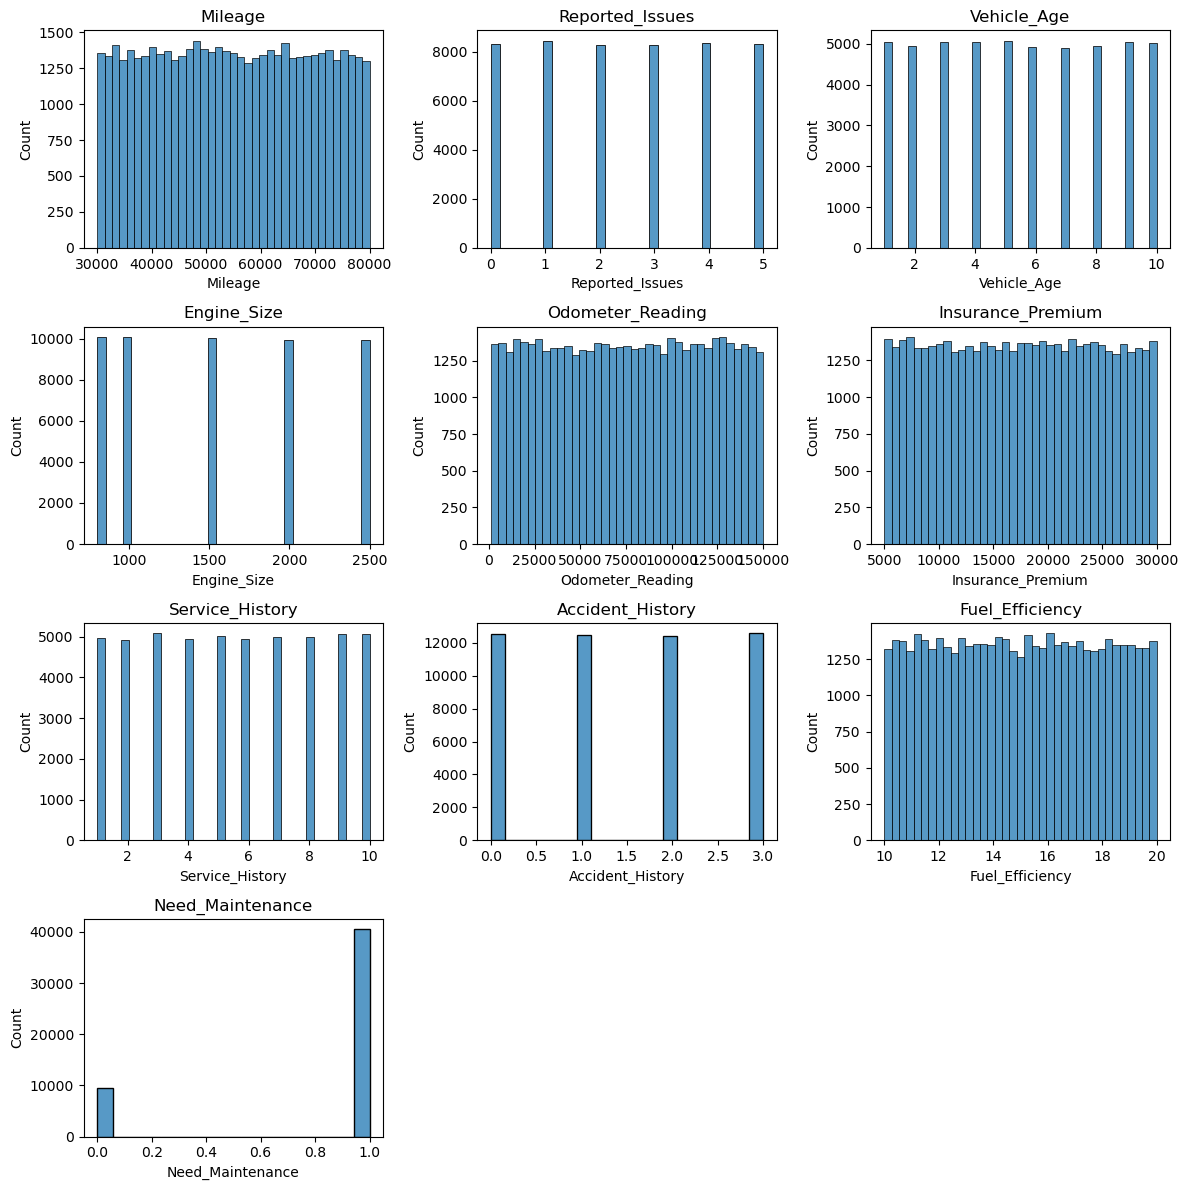

In [14]:
# Univariate Analysis: Numerical Features
import math

# Identify numeric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
n = len(num_cols)
n_cols = 3
n_rows = math.ceil(n / n_cols)

plt.figure(figsize=(n_cols * 4, n_rows * 3))
for i, col in enumerate(num_cols, start=1):
    ax = plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col].dropna(), kde=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()

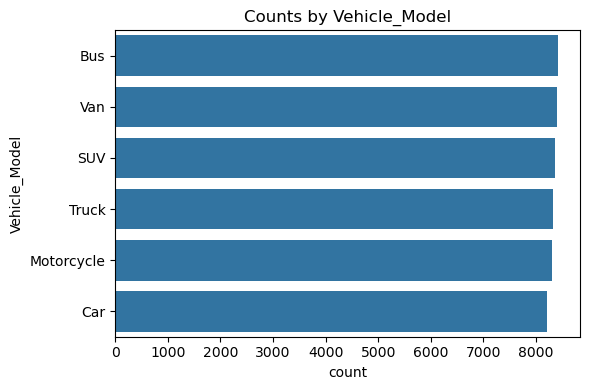

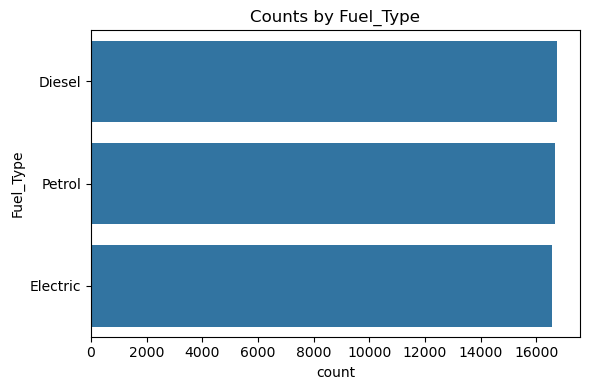

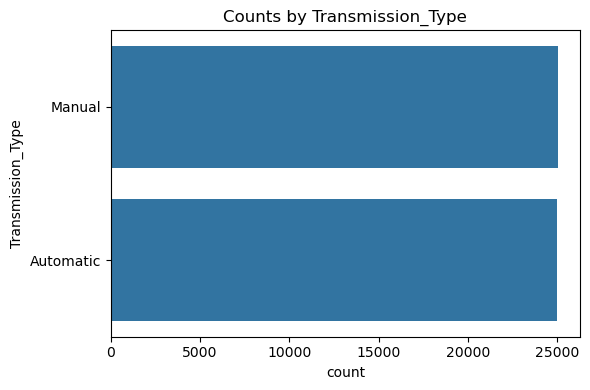

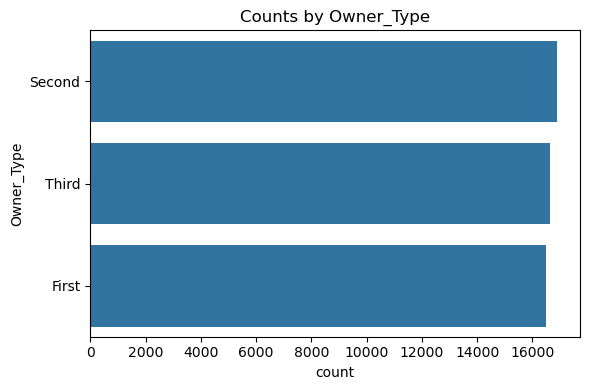

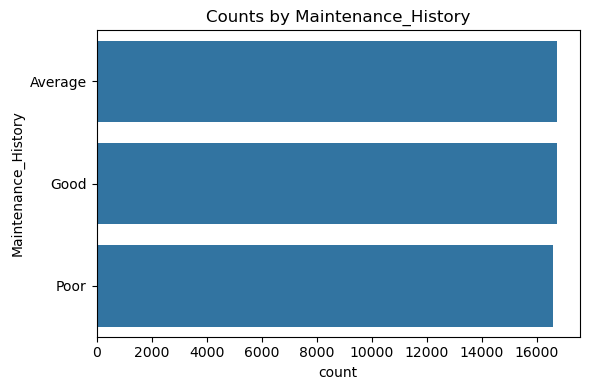

In [16]:
# Univariate Analysis: Categorical Features
cat_cols = [
    "Vehicle_Model",
    "Fuel_Type",
    "Transmission_Type",
    "Owner_Type",
    "Maintenance_History"
]

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f"Counts by {col}")
    plt.tight_layout()

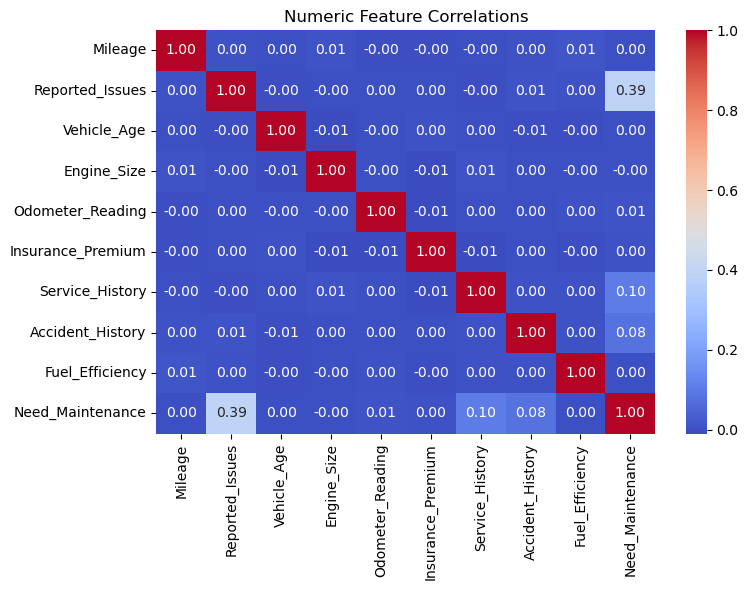

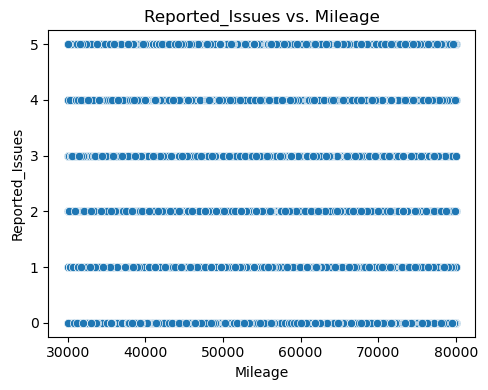

In [18]:
# Bivariate Analysis: Correlation & Scatter
# Correlation heatmap for numeric features
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Numeric Feature Correlations")
plt.tight_layout()

x_col = "vehicle_age" if "vehicle_age" in df.columns else num_cols[0]
y_col = "miles" if "miles" in df.columns else (num_cols[1] if len(num_cols) > 1 else num_cols[0])

plt.figure(figsize=(5, 4))
sns.scatterplot(data=df, x=x_col, y=y_col)
plt.title(f"{y_col} vs. {x_col}")
plt.tight_layout()

In [21]:
# Handle Missing Values & Outliers
for col in ["Mileage", "Vehicle_Age", "Engine_Size"]:
    df[col] = df[col].fillna(df[col].median())

df = df.dropna(subset=["Last_Service_Date", "Maintenance_History"])

cap = df["Mileage"].quantile(0.99)
df["Mileage"] = df["Mileage"].clip(upper=cap)

### Feature Engineering

In [27]:
# Binning & Ratios
age_max = int(df["Vehicle_Age"].max())
bins_age = list(range(0, age_max + 5, 5))
labels_age = [f"{i}-{i+4}" for i in bins_age[:-1]]
df["age_bin"] = pd.cut(df["Vehicle_Age"], bins=bins_age, labels=labels_age, right=False)

df["mileage_per_year"] = df["Mileage"] / df["Vehicle_Age"].replace(0, 1)

max_m = df["Mileage"].max()
max_bin = int(np.ceil(max_m / 30000)) * 30000
bins_miles = list(range(0, max_bin + 1, 30000))
labels_miles = [f"{int(bins_miles[i]/1000)}-{int(bins_miles[i+1]/1000)}k"
                for i in range(len(bins_miles)-1)]
df["miles_bucket"] = pd.cut(df["Mileage"], bins=bins_miles, labels=labels_miles, right=False)

In [30]:
# Date Features
df["Last_Service_Date"] = pd.to_datetime(df["Last_Service_Date"], errors="coerce")
today = pd.Timestamp.today()

# Extract year and month
df["service_year"] = df["Last_Service_Date"].dt.year
df["service_month"] = df["Last_Service_Date"].dt.month

# Calculate months since service as difference in months
df["months_since_service"] = (
    (today.year - df["Last_Service_Date"].dt.year) * 12
    + (today.month - df["Last_Service_Date"].dt.month)
)


In [32]:
# Categorical Encoding
from sklearn.preprocessing import OneHotEncoder

cat_feats = ["Vehicle_Model", "Fuel_Type", "Transmission_Type", "Owner_Type"]
# Use sparse_output instead of deprecated sparse parameter
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = pd.DataFrame(
    ohe.fit_transform(df[cat_feats]),
    columns=ohe.get_feature_names_out(cat_feats),
    index=df.index
)

# Drop original categorical columns and append encoded features
df = pd.concat([df.drop(columns=cat_feats), encoded], axis=1)


In [33]:
# Final Check
print("Final shape:", df.shape)
display(df.head())

Final shape: (50000, 36)


,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Insurance_Premium,Service_History,...,Vehicle_Model_Truck,Vehicle_Model_Van,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Petrol,Transmission_Type_Automatic,Transmission_Type_Manual,Owner_Type_First,Owner_Type_Second,Owner_Type_Third
0,58765.0,Good,0,4,2000,28524,2023-11-23,6/24/2025,20782,6,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,60353.0,Average,1,7,2500,133630,2023-09-21,6/4/2025,23489,7,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,68072.0,Poor,0,2,1500,34022,2023-06-27,4/27/2025,17979,7,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,60849.0,Average,4,5,2500,81636,2023-08-24,11/5/2025,6220,7,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,45742.0,Poor,5,1,2000,97162,2023-05-25,9/14/2025,16446,6,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
